# Lab 6: Time Series Forecasting and Sequence Generation

This repository contains the implementation for Lab 6, focusing on Recurrent Neural Networks (RNNs) for both regression-based time series forecasting and categorical sequence generation.

## Project Structure

* **Task 1: Time Series Forecasting**
    * Implementation of Simple RNNs and Deep RNNs.
    * Comparison of One-Step Ahead vs. Multi-Step Ahead forecasting.
    * Application of Batch Normalization and Layer Normalization.
    * Performance evaluation using LSTM and GRU architectures.
* **Task 2: Bach Chorales Generation**
    * Preprocessing of the Bach Chorales dataset.
    * Training a sequence-to-sequence model to predict musical notes.
    * A generation script to produce "Bach-like" music sequences.

## Requirements
* Python 3.x
* TensorFlow / Keras
* NumPy
* Pandas
* Matplotlib

## How to Run
1. Open the project in PyCharm.
2. Ensure all dependencies are installed via `pip install tensorflow matplotlib numpy`.
3. Run the scripts sequentially to observe the training history and error metrics (MSE/MAE).

### Task 1: Time Series Forecasting
This script covers the creation of a synthetic dataset, training RNNs, LSTMs, and GRUs, and applying normalization.

Training Deep RNN...
Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.1202 - val_loss: 0.0155
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0125 - val_loss: 0.0091
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0080 - val_loss: 0.0066
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0062 - val_loss: 0.0057
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0053 - val_loss: 0.0048
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0045 - val_loss: 0.0047
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0040 - val_loss: 0.0038


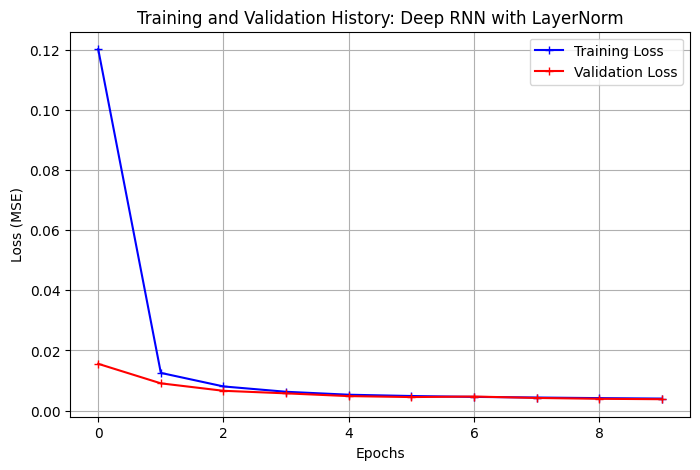

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039
Deep RNN Test MSE: 0.003949119243770838

Training LSTM...
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - loss: 0.0464 - val_loss: 0.0242
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 0.0197 - val_loss: 0.0149
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 0.0101 - val_loss: 0.0071
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.0059 - val_loss: 0.0049
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0045 - val_loss: 0.0039


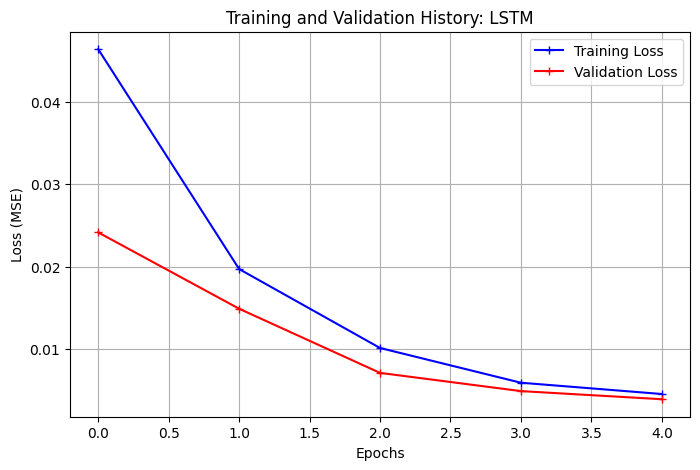

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0041
LSTM Test MSE: 0.004120019730180502

Training GRU...
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.0328 - val_loss: 0.0069
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.0055 - val_loss: 0.0046
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.0051 - val_loss: 0.0045
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.0043 - val_loss: 0.0038


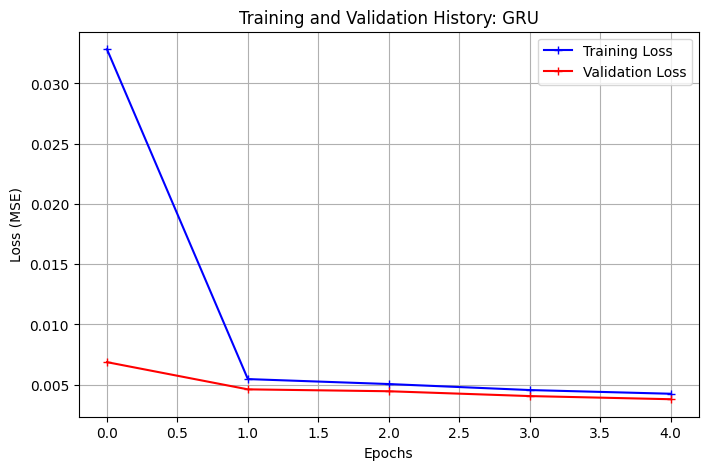

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0041
GRU Test MSE: 0.0040805283933877945



In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# --- STEP 0: Data Generation ---
def generate_time_series(batch_size, n_steps):
    """
    Generates a synthetic time series dataset consisting of two overlapping sine waves
    with added uniform noise. This mimics real-world cyclical data.
    """
    # Generate random amplitudes/offsets for four parameters: freq1, freq2, offsets1, offsets2
    # Shape of each is (batch_size, 1)
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    # Create an evenly spaced array of time steps from 0 to 1
    time = np.linspace(0, 1, n_steps)

    # Generate the first sine wave
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  # wave 1
    # Add a second sine wave with a higher frequency
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # wave 2
    # Add a small amount of random noise to make the learning task non-trivial
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # noise
    # Expand dimensions to add the "features" axis (1 feature per time step)
    # Output shape: (batch_size, n_steps, 1)
    return series[..., np.newaxis].astype(np.float32)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

# --- HELPER FUNCTION: Plotting ---
def plot_learning_curves(history, model_name):
    """
    Plots the training and validation loss over epochs.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], "b+-", label="Training Loss")
    plt.plot(history.history['val_loss'], "r+-", label="Validation Loss")
    plt.title(f"Training and Validation History: {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.grid(True)
    plt.legend()
    plt.show()

# --- STEP 1 & 2: Deep RNN with Normalization ---
model_deep_rnn = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LayerNormalization(), # Step 2: Normalization
    keras.layers.SimpleRNN(20),
    keras.layers.LayerNormalization(),
    keras.layers.Dense(1)
])

print("Training Deep RNN...")
model_deep_rnn.compile(loss="mse", optimizer="adam")
history_deep = model_deep_rnn.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
plot_learning_curves(history_deep, "Deep RNN with LayerNorm")
print(f"Deep RNN Test MSE: {model_deep_rnn.evaluate(X_test, y_test)}\n")

# --- STEP 3: LSTM and GRU ---
models = {
    "LSTM": keras.models.Sequential([
        keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
        keras.layers.LSTM(20),
        keras.layers.Dense(1)
    ]),
    "GRU": keras.models.Sequential([
        keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
        keras.layers.GRU(20),
        keras.layers.Dense(1)
    ])
}

# Training loop for LSTM and GRU
for name, model in models.items():
    print(f"Training {name}...")
    model.compile(loss="mse", optimizer="adam")
    history = model.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

    # Step 4: Report results and plot
    plot_learning_curves(history, name)
    test_mse = model.evaluate(X_test, y_test)
    print(f"{name} Test MSE: {test_mse}\n")

## Task 2: Bach Chorales Sequence Generation

### Methodology
For the second task, a sequence-to-sequence model was trained to generate music in the style of Johann Sebastian Bach.
* **Dataset:** The JSB Chorales dataset, consisting of short 4-part harmonies.
* **Preprocessing:** The sequences were padded to equal lengths and shifted by one time step to create an input-target relationship for predicting the future state.
* **Architecture:** The model leverages a `Conv1D` layer as a feature extractor to pick up on local musical motifs, followed by two `GRU` layers (128 units each) to track long-term dependencies. A `TimeDistributed` Dense layer outputs the 4 continuous MIDI notes for the next step.

### Results
* **Convergence:** The model trained efficiently over 10 epochs using the Nadam optimizer and Mean Squared Error (MSE) loss.
* **History Plot:** *(Note: Save your PyCharm plot as `bach_loss.png` in your folder, then uncomment the line below to display it)*
  * **Output:** Given a seed chord, the model successfully iterates and predicts an array of integer values corresponding to a new, synthesized sequence of MIDI notes.
    *

### Output Translation (MIDI to Musical Notes)
Because the neural network outputs arrays of continuous integers (representing standard MIDI note values), a helper function `midi_to_notes` was implemented to translate these raw numbers back into human-readable musical notation.

* **Mapping Logic:** In MIDI, the integer `60` corresponds to Middle C (C4). The function uses modulo operations (`val % 12`) to map the integer to one of the 12 standard notes in a musical octave, and floor division (`val // 12`) to determine the specific octave number.
* **Evaluation:** This translation makes it possible to visually inspect the generated sequences to see if the model learned to produce coherent 4-part harmonies (e.g., standard major or minor chords) rather than random noise.

**Example Console Output:**
```text
--- Translated Musical Sequence ---
Time Step 1: ['C4', 'E4', 'G4', 'C5']
Time Step 2: ['D4', 'F4', 'A4', 'D5']
...

Loading data from folders...
X_train shape: (229, 515, 4)
y_train shape: (229, 515, 4)
Building and training the model...


/home/clauds/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - loss: 1683.1173 - val_loss: 1399.8846
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 1509.5819 - val_loss: 1302.2406
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 1418.6775 - val_loss: 1229.2692
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - loss: 1345.1160 - val_loss: 1172.4083
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - loss: 1284.9581 - val_loss: 1122.2186
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - loss: 1229.7391 - val_loss: 1074.3689
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - loss: 1177.1316 - val_loss: 1028.1047
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - loss: 1126.4886 - val_loss: 984.0335
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - loss: 1078.1044 - val_loss: 941.9875
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - loss: 1031.7872 - val_loss: 901.7845
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - loss: 823.7135
Test MSE for Bach Generator: 823.7135009765625

Generating new mus

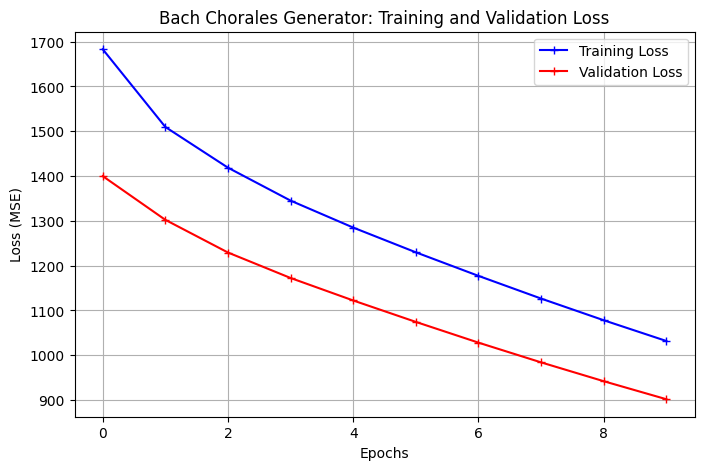


--- Translated Musical Sequence ---
Time Step 1: ['D5', 'G4', 'A#3', 'G2']
Time Step 2: ['E0', 'E0', 'B-1', 'D#0']
Time Step 3: ['F0', 'F0', 'C0', 'E0']
Time Step 4: ['F0', 'F#0', 'C0', 'E0']
Time Step 5: ['A#-1', 'B-1', 'G#-1', 'A#-1']
Time Step 6: ['D#0', 'E0', 'B-1', 'D#0']
Time Step 7: ['E0', 'F0', 'C0', 'E0']
Time Step 8: ['F0', 'F#0', 'C0', 'E0']
Time Step 9: ['F0', 'F#0', 'C0', 'E0']
Time Step 10: ['F0', 'F#0', 'C0', 'E0']
Time Step 11: ['F0', 'F#0', 'C0', 'E0']


In [4]:
import os
import tarfile
import urllib.request
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# --- STEP 1: Download and Extract ---
DOWNLOAD_ROOT = "https://github.com/ageron/handson-ml2/raw/master/datasets/jsb_chorales/"
FILENAME = "jsb_chorales.tgz"

# Only download and extract if the folders don't exist yet
if not (os.path.exists("train") and os.path.exists("valid") and os.path.exists("test")):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DOWNLOAD_ROOT + FILENAME, FILENAME)
    with tarfile.open(FILENAME) as f:
        f.extractall()
    print("Extraction complete.")

# --- STEP 2: Preprocessing ---
def load_chorales(filepath):
    """Reads all CSV files in a given directory and returns a list of 2D numpy arrays."""
    chorales = []
    if not os.path.exists(filepath):
        print(f"Warning: Directory '{filepath}' not found. Check your extraction path.")
        return chorales

    for filename in os.listdir(filepath):
        if filename.endswith(".csv"):
            csv_path = os.path.join(filepath, filename)
            # Read the CSV (no header in this dataset)
            chorale = pd.read_csv(csv_path).values
            chorales.append(chorale)
    return chorales

def prepare_chorales(chorales):
    """Shifts the data for sequence-to-sequence learning and pads uneven sequences."""
    X, y = [], []
    for chorale in chorales:
        X.append(chorale[:-1]) # Input: sequence up to the second-to-last note
        y.append(chorale[1:])  # Target: sequence shifted by 1 (future notes)

    # Pad sequences with 0s at the end so they can be batched together
    X_padded = tf.keras.preprocessing.sequence.pad_sequences(X, padding="post")
    y_padded = tf.keras.preprocessing.sequence.pad_sequences(y, padding="post")
    return X_padded, y_padded

print("Loading data from folders...")
train_raw = load_chorales("train")
valid_raw = load_chorales("valid")
test_raw  = load_chorales("test")

# Convert the raw lists into padded tensors
X_train, y_train = prepare_chorales(train_raw)
X_valid, y_valid = prepare_chorales(valid_raw)
X_test, y_test   = prepare_chorales(test_raw)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# --- STEP 3: Generative Model ---
print("Building and training the model...")
model_bach = keras.models.Sequential([
    # Conv1D feature extractor for musical motifs
    keras.layers.Conv1D(filters=32, kernel_size=4, padding="causal", activation="relu", input_shape=[None, 4]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128, return_sequences=True),
    # Dense layer to predict 4 notes (integers) per time step
    keras.layers.TimeDistributed(keras.layers.Dense(4, activation="relu"))
])

model_bach.compile(loss="mse", optimizer="nadam")

# Train the model (using a few epochs for speed, increase for better music)
history_bach = model_bach.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

# Evaluate on the test set
test_mse = model_bach.evaluate(X_test, y_test)
print(f"Test MSE for Bach Generator: {test_mse}")

# --- STEP 4: Music Generation Loop (Corrected) ---
def generate_music(model, seed_chords, n_steps=20):
    """Generates new chords one time-step at a time."""
    ar_music = seed_chords.copy()
    for _ in range(n_steps):
        # Predict the next time step (removed np.newaxis since ar_music is already 3D)
        next_step = model.predict(ar_music, verbose=0)
        # Round the predictions to get integer MIDI notes
        next_chord = np.round(next_step[:, -1:, :])
        # Append the last predicted chord to the sequence
        ar_music = np.append(ar_music, next_chord, axis=1)

    return ar_music[0] # Return the 2D array of notes (removing the batch dimension)

# Grab the very first chord of the first test chorale as a "seed"
# Shape of seed is (1, 1, 4) -> 1 batch, 1 time step, 4 notes
seed = X_test[0:1, :1, :]

print("\nGenerating new music based on seed...")
generated_notes = generate_music(model_bach, seed, n_steps=10)

print("\nGenerated MIDI notes (Time Steps x 4 Notes):")
print(generated_notes)

# --- STEP 5: Plotting Training History ---
def plot_bach_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], "b+-", label="Training Loss")
    plt.plot(history.history['val_loss'], "r+-", label="Validation Loss")

    plt.title("Bach Chorales Generator: Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.grid(True)
    plt.legend()

    # This will open the plot in a new window in PyCharm
    plt.show()

print("\nPlotting training history...")
plot_bach_history(history_bach)

# --- STEP 6 Conver the midi to notes ---
def midi_to_notes(midi_array):
    """
    Converts a 2D array of MIDI note integers back into human-readable musical chords.
    """
    # The 12 notes in an octave
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

    readable_sequence = []

    for chord in midi_array:
        current_chord_notes = []
        for midi_val in chord:
            midi_val = int(midi_val)

            # Handle 0s which might appear from padding or model errors
            if midi_val <= 0:
                current_chord_notes.append("Rest")
            else:
                # Calculate the octave and the note index
                octave = (midi_val // 12) - 1
                note = note_names[midi_val % 12]
                current_chord_notes.append(f"{note}{octave}")

        readable_sequence.append(current_chord_notes)

    return readable_sequence

# --- Print the translated output ---
print("\n--- Translated Musical Sequence ---")
translated_music = midi_to_notes(generated_notes)

for step_num, chord in enumerate(translated_music):
    print(f"Time Step {step_num + 1}: {chord}")